# Categorical Variables Association

**Association** measures the relationship between two categorical variables.

In [1]:
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

## Example 1: Titanic Survival and Class

**Question**:

- People in higher `pclass` on the titanic may have had access to life boats or may have been simply treated better.
- Is there an association between that and whether they `survived` or not?

Let's find out..

In [2]:
titanic = sns.load_dataset('titanic')
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


### Contingency Table

A **Contingency Table** displays the joint frequency of two or more categorical variables as follows:

- Categories: One variable is assigned to the rows, and the other is assigned to the columns.
- Cells: The intersections containing the frequency (the exact count) of data points that match both the row and column categories.

In [3]:
contingency_table = pd.crosstab(
    index=titanic['pclass'],
    columns=titanic['survived'],
)
contingency_table

survived,0,1
pclass,,
1,80,136
2,97,87
3,372,119


Let's try three variables for the sake of understanding how it is displayed:

In [4]:
contingency_table_3 = pd.crosstab(
    index=[titanic['pclass'],
    titanic['sex']],
    columns=titanic['survived']
)
contingency_table_3

survived         0   1
pclass sex            
1      female    3  91
       male     77  45
2      female    6  70
       male     91  17
3      female   72  72
       male    300  47

Let's look at it's index:

In [5]:
contingency_table_3.index

MultiIndex([(1, 'female'),
            (1,   'male'),
            (2, 'female'),
            (2,   'male'),
            (3, 'female'),
            (3,   'male')],
           names=['pclass', 'sex'])

The index tells us that we can reach a specific value as follows:

In [6]:
print(contingency_table_3.loc[(2, 'male'), 0])

91


### Relative Frequency

We are interested in the frequency distribution of the target `survived` per `pclass`:

In [7]:
contingency_table_normalized = pd.crosstab(
    index=titanic['pclass'],
    columns=titanic['survived'],
    
    normalize='index' # Added
)
contingency_table_normalized

survived,0,1
pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


Using a `heatmap` to add color and intensity makes it easier to read and compare:

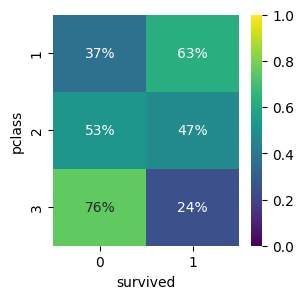

In [8]:
plt.figure(figsize=(3, 3))
sns.heatmap(
    contingency_table_normalized,
    annot=True, cmap="viridis", fmt=".0%", vmin=0, vmax=1
);

In the heatmap above, do you observe a relationship between the two variables?

Let's check it out, statistically.

[**Chramer's V**](https://en.wikipedia.org/wiki/Cram%C3%A9r%27s_V) is a measure of association between two nominal variables, giving a value between 0 and +1 (inclusive):

- `0` (no association)
- `1` (perfect association)

It may be viewed as a percentage of maximum possible variation.

In [ ]:
from utils import test_association

chramer_v, is_significant = test_association(contingency_table)
print(round(chramer_v, 2))
if is_significant:
    print('signiciant')

0.34
signiciant


## Example 2: Sex and Occupation

In this example, we'll use the [Adult Dataset from UCI](https://archive.ics.uci.edu/dataset/2/adult).

**Question**: are there gender differences between preferences of occupations?

In [ ]:
data_path = Path('../data/adult.csv')
adult = pd.read_csv(data_path)
adult

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [16]:
# Create a dictionary mapping the original labels to the meaningful names
occupation_mapping = {
    'Tech-support': 'Technical Support',
    'Craft-repair': 'Skilled Trades & Repair',
    'Other-service': 'General Service',
    'Exec-managerial': 'Executive & Managerial',
    'Prof-specialty': 'Professional Specialty',
    'Handlers-cleaners': 'Handlers & Cleaners',
    'Machine-op-inspct': 'Machine Operators & Inspectors',
    'Adm-clerical': 'Administrative & Clerical',
    'Farming-fishing': 'Farming & Fishing',
    'Transport-moving': 'Transportation & Moving',
    'Priv-house-serv': 'Private Household Services',
    'Protective-serv': 'Protective Services',
    'Armed-Forces': 'Armed Forces'
}

# Apply the replacement directly to the occupation column
adult['occupation'] = adult['occupation'].replace(occupation_mapping)

Create a contingency table to analyze the association between `sex` and `occupation`:

In [17]:
adult_contingency_table_normalized = pd.crosstab(
    index=adult['occupation'],
    columns=adult['sex'],
    normalize='index'
)
adult_contingency_table_normalized

sex,Female,Male
occupation,,
Administrative & Clerical,0.672944,0.327056
Armed Forces,0.000000,1.000000
Executive & Managerial,0.285047,0.714953
Farming & Fishing,0.065392,0.934608
General Service,0.546282,0.453718
Handlers & Cleaners,0.119708,0.880292
Machine Operators & Inspectors,0.274725,0.725275
Private Household Services,0.946309,0.053691
Professional Specialty,0.365942,0.634058


Using a `heatmap` to add color and intensity makes it easier to read and compare:

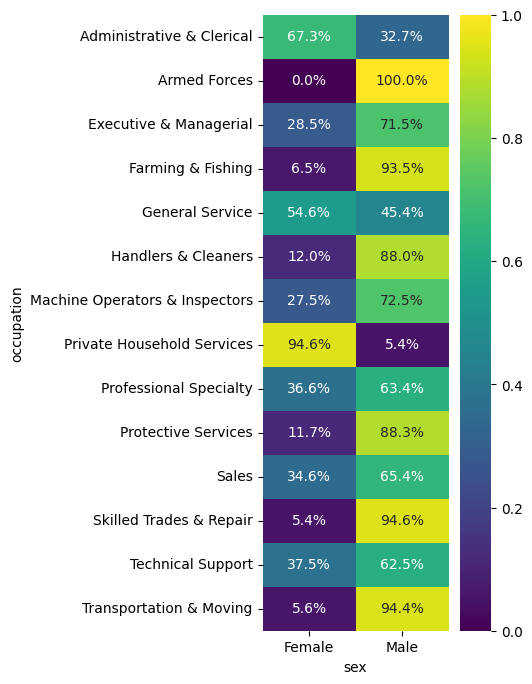

In [18]:
plt.figure(figsize=(3, 8))
sns.heatmap(
    adult_contingency_table_normalized,
    annot=True, cmap="viridis", fmt=".1%", vmin=0, vmax=1
);

### Chramer's V

In [19]:
adult_contingency_table = pd.crosstab(
    index=adult['occupation'],
    columns=adult['sex'],
)
adult_contingency_table

sex,Female,Male
occupation,,
Administrative & Clerical,2537,1233
Armed Forces,0,9
Executive & Managerial,1159,2907
Farming & Fishing,65,929
General Service,1800,1495
Handlers & Cleaners,164,1206
Machine Operators & Inspectors,550,1452
Private Household Services,141,8
Professional Specialty,1515,2625


In [20]:
from utils import test_association

chramer_v, is_significant = test_association(adult_contingency_table)
print(round(chramer_v, 2))
if is_significant:
    print('signiciant')

0.43
signiciant
